# Car example

from lecture!

In [37]:
# Packages etc
import numpy as np                              # General math
import matplotlib.pyplot as plt                 # For plotting

In [38]:
# Tableau 10 color scheme (hex)
tabBlue   = "#4E79A7"
tabGreen  = "#59A14F"
tabBrown  = "#9C755F"
tabOrange = "#F28E2B"
tabYellow = "#EDC948"
tabGray   = "#BAB0AC"
tabRed    = "#E15759"
tabPurple = "#B07AA1"
tabTeal   = "#76B7B2"
tabPink   = "#FF9DA7"

## Physics

In [39]:
# Car parameters
k = 15e3       # Engine acceleration coefficient (N)
m = 1200    # car mass  (kg)
c = 200    # Friction factor air
T_dead = 0.6
F_dist = 0    # Distortion, may be from engine itself

In [40]:
# "Make a step", so getting the new state from the old state after one dt timestep considering the actions
def step(state, action, dt):
    # Read state and action
    x, x_dot = state              # position, velocity (current state)
    u = action                      # Throttle pedal position (in %)

    # Definition of the differential equation
    x_ddot = (k * (u-u**2/2) - c * x_dot - F_dist) / m    # Acceleration nonlinear ODE

    # Explicit Euler update
    x_new         = x         + dt * x_dot
    x_dot_new     = x_dot     + dt * x_ddot

    return np.array([x_new, x_dot_new])

## Simulation

In [41]:
# Simulation parameters
dt = 1e-2           # Step size (smaller is numerically more stable, but needs more time to calculate)
time_total = 10      # Total time
steps = int(time_total / dt)    # Number of simulation steps

# For plotting we need to save the states over time
time = np.linspace(0, time_total, steps)

def simulation(initial_state, actor_function):
    # log only x, v
    states_log = np.zeros((steps, 2))
    action_log = np.zeros(steps)

    # internal state includes u_eff
    state = np.array(initial_state, dtype=float)  # [x, v, u_eff]

    # initial log
    states_log[0, :] = state[:2]

    # Motor has dead time
    d = int(T_dead / dt)           # Totzeit in Schritten
    buf = np.zeros(d)              # startet mit 0

    for i in range(steps - 1):
        t = i * dt

        u = 0.0 if actor_function is None else actor_function(state, t)
        action_log[i] = u

        u_in = u if d == 0 else buf[0]   # verzögertes u
        if d:
            buf[:-1] = buf[1:]
            buf[-1]  = u

        state = step(state, u_in, dt)        # step bekommt u_in
        states_log[i + 1, :] = state[:2] # log only x, v

    action_log[-1] = action_log[-2]
    return states_log, action_log


## Plots

In [42]:
# Plot of the state over time
def show_plots(x_dot, u, v_set = None, title = None):
    plt.close('all')
    fig, axs = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    
    labels = [r'Velocity $v\,[\mathrm{m/s}]$', r'Throttle $u\,[-]$']
    colors = [tabBlue, tabGreen, tabRed]

    if v_set is not None:
        axs[0].axhline(y = v_set, color=tabOrange,linestyle='--', label=r"$r(t)$", linewidth=2)

    axs[0].plot(time, x_dot[:, 1], colors[0], label=r"$v(t)$", linewidth=2)
    axs[0].set_ylabel(labels[0])
    axs[0].set_ylim(min(np.min(x_dot[:, 1]), max(np.max(x_dot[:, 1]), v_set) * 1.01))
    axs[0].legend(loc="lower right")
    axs[0].grid()

    axs[1].plot(time, u[:], colors[2], linewidth=2)
    axs[1].set_ylabel(labels[1])
    axs[1].set_ylim(0, 1.01)
    axs[1].grid()
        
    axs[-1].set_xlim(0, time[-1])
    axs[-1].set_xlabel(r'Time $t$ [s]')
    if title is None:
        fig.suptitle("States and actions over time", fontsize=14)    
    else:
        fig.suptitle(title, fontsize=14)    
    plt.tight_layout()

    if title:
        plt.savefig(title + ".pdf")
    plt.show()

## PID

In [43]:
def make_af_pid(v_set, Kp, Ki, Kd, u_max=1.0):
    integral = 0.0
    last_error = 0.0

    def pid_actor(state, t):
        nonlocal integral, last_error

        # Get state (
        # keep in mind: we just measure theta in reality, since this is the sensor output y(t) --> We have to work only with theta
        v = state[1]
        error = v_set - v

        integral += error * dt
        integral = np.clip(integral, -1.0, 1.0)  # anti-windup: Prevents extreme integral values for long integration times

        derivative = (error - last_error) / dt
        last_error = error

        u = Kp * error + Ki * integral + Kd * derivative     # Actor needs to work against the error!

        return np.clip(u, 0, u_max)

    return pid_actor

In [44]:
# Get initial state (standing vehicle)
init_state = np.array([
    0,                           # x
    0                           # x_dot
])

# Set the desired velocity!
v_set = 10   # Set wanted velocity (m/s)

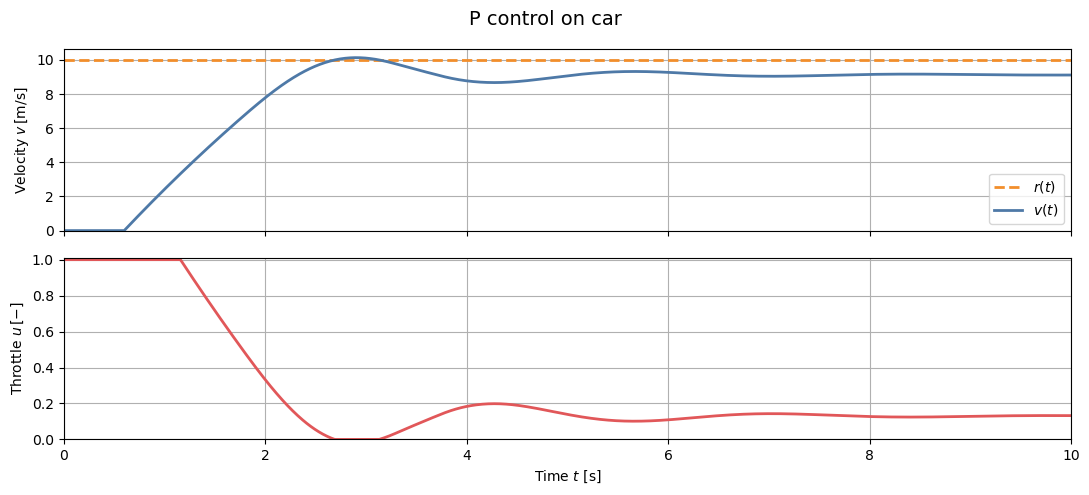

In [81]:
# Simple P tuner
v_P, u_P = simulation(init_state, actor_function=make_af_pid(v_set=v_set, Kp=0.15, Ki=0, Kd=0))
show_plots(v_P, u_P, v_set=v_set, title="P control on car")

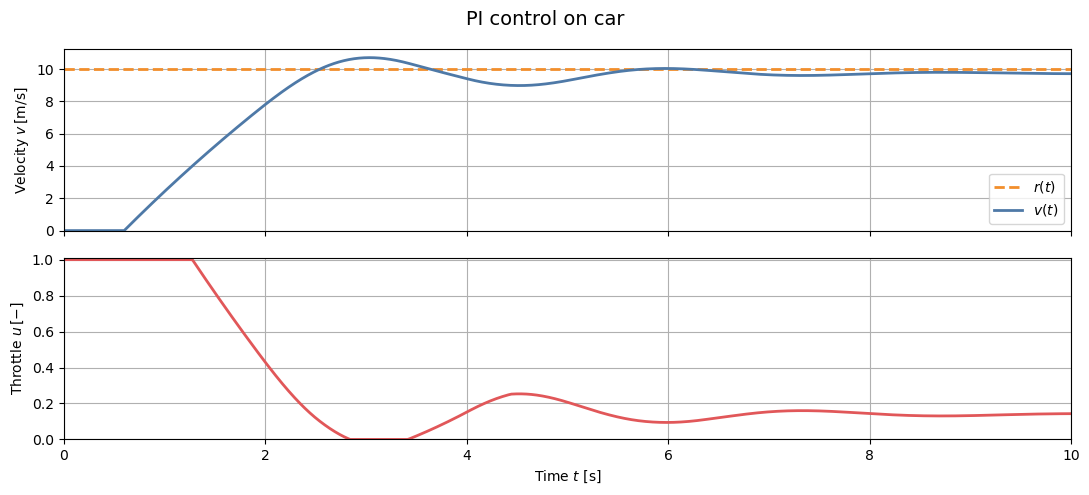

In [82]:
# PI tuner

v_PI, u_PI = simulation(init_state, actor_function=make_af_pid(v_set=v_set, Kp=0.15, Ki=0.1, Kd=0))
show_plots(v_PI, u_PI, v_set=v_set, title="PI control on car")

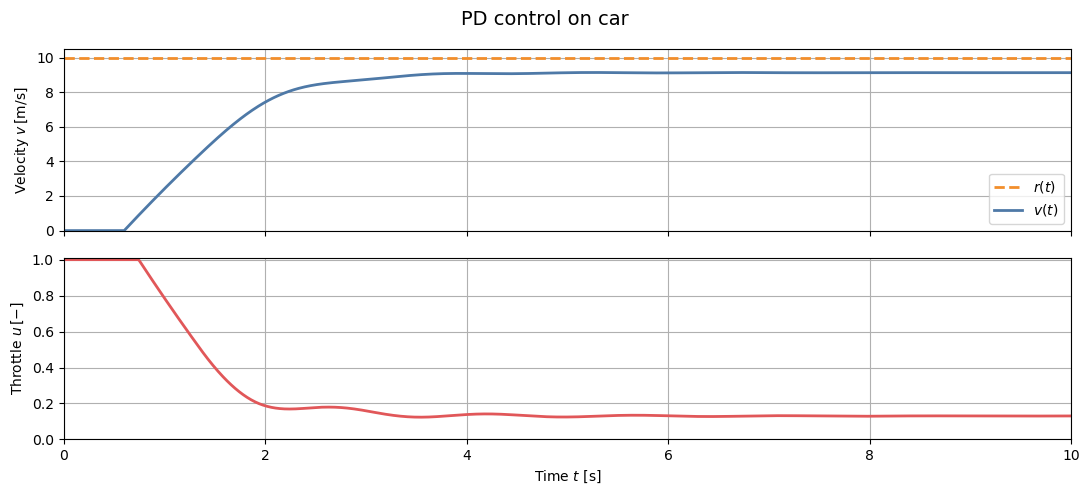

In [83]:
# PD tuner

v_PD, u_PD = simulation(init_state, actor_function=make_af_pid(v_set=v_set, Kp=0.15, Ki=0, Kd=0.06))
show_plots(v_PD, u_PD, v_set=v_set, title="PD control on car")

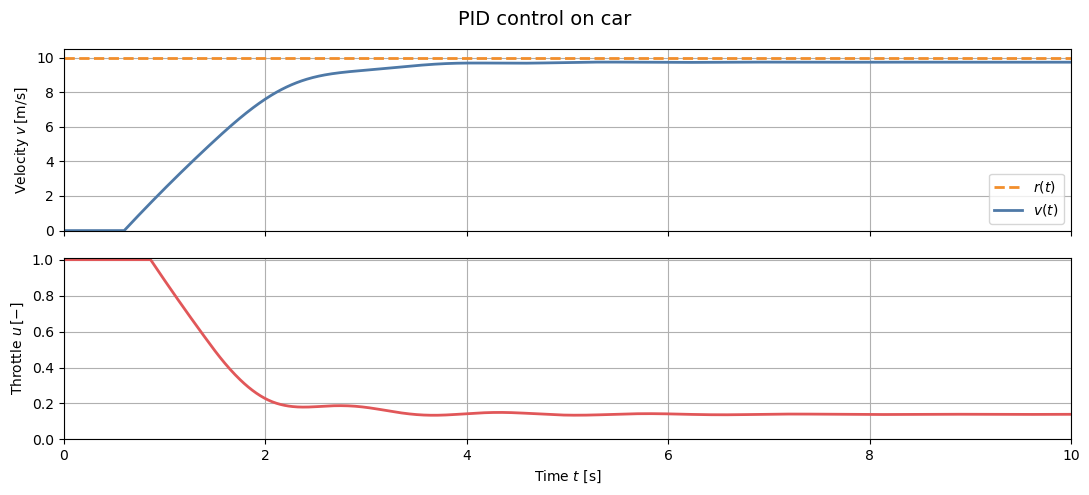

In [84]:
# PID tuner

v_PID, u_PID = simulation(init_state, actor_function=make_af_pid(v_set=v_set, Kp=0.15, Ki=0.1, Kd=0.06))
show_plots(v_PID, u_PID, v_set=v_set, title="PID control on car")

# Ziegler-Nichols method

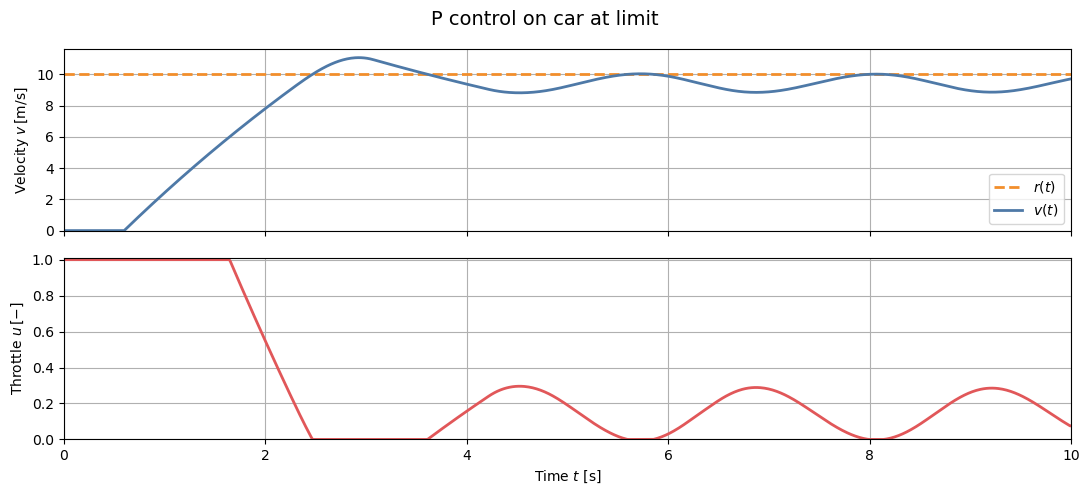

In [85]:
# Simple P tuner
Ku = 0.25  # Change till steady oscillations
v_ZN, u_ZN = simulation(init_state, actor_function=make_af_pid(v_set=v_set, Kp=Ku, Ki=0, Kd=0))
show_plots(v_ZN, u_ZN, v_set=v_set, title="P control on car at limit")

In [86]:
# Ziegler-Nichols
Tu = 2.2    # Read "by eye"

# Get from table
Kp_ZN = 0.6*Ku
Ki_ZN = 1.2*Ku/Tu
Kd_ZN = 0.075*Ku*Tu

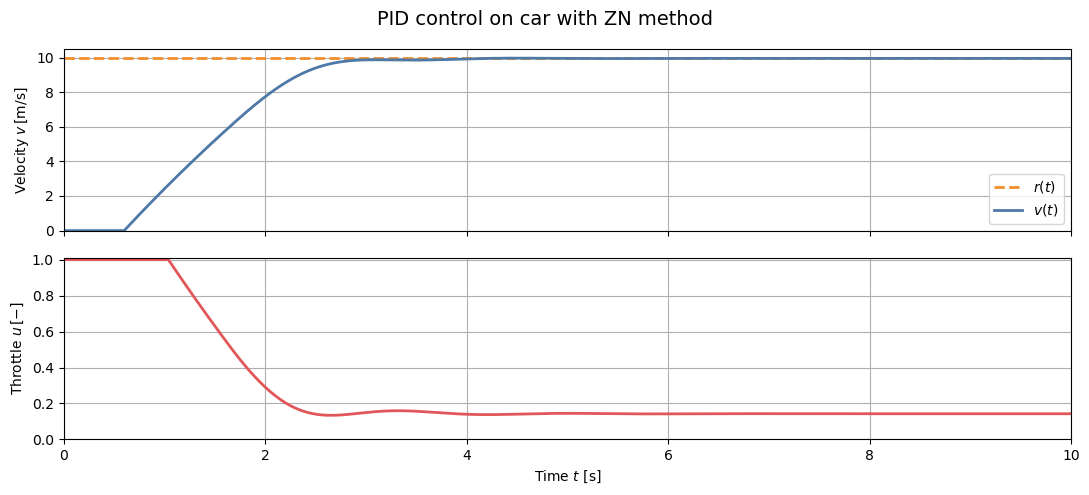

In [87]:
# ZN tuned PID

v_ZN, u_ZN = simulation(init_state, actor_function=make_af_pid(v_set=v_set, Kp=Kp_ZN, Ki=Ki_ZN, Kd=Kd_ZN))
show_plots(v_ZN, u_ZN, v_set=v_set, title="PID control on car with ZN method")

# LQR

Version 1: Linearization in $..$ (0)

In [88]:
def get_u_from_v(v_set):
    return 1 - np.sqrt(1-2*c*v0/k)

v0 = 10
u0 = get_u_from_v(v0)

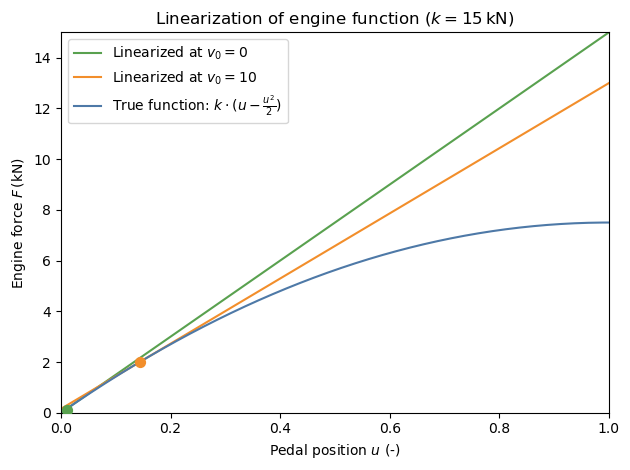

In [89]:
# Linearization of engine function
u = np.linspace(0, 1, 400)
plt.plot(u, k * u * 1e-3, tabGreen, label=r"Linearized at $v_0=0$")
plt.plot(u, k * (u0**2 /2 + u * (1-u0)) * 1e-3, tabOrange, label=r"Linearized at $v_0=10$")
plt.plot(u, k * (u-u**2/2) * 1e-3, tabBlue, label=r"True function: $k \cdot (u-\frac{u^2}{2})$")
plt.scatter(0.01, 0.1, marker='o', s=50, color=tabGreen, zorder=10)
plt.scatter(u0, v0*c *1e-3, marker='o', s=50, color=tabOrange, zorder=10)
plt.xlabel(r"Pedal position $u$ (-)")
plt.ylabel(r"Engine force $F\,(\mathrm{kN})$")
plt.title(r"Linearization of engine function ($k=15\,\mathrm{kN}$)")
plt.xlim(0,1)
plt.ylim(0,k*1e-3)
plt.legend()
plt.tight_layout()
plt.savefig("engine_function_2.pdf")
plt.show()
plt.close()

In [90]:
# State space representation (in u_0 = 0 and x_0 = [0, 0])
A = np.array([[0.0, 1.0],[0.0, -c/m]], dtype=float)

B = np.array([[0.0],[k/m]], dtype=float)

C = np.array([[0.0, 1.0]], dtype=float)

D = np.array([[0.0]], dtype=float)

In [91]:
# Stability
print(np.linalg.eigvals(A))

[ 0.         -0.16666667]


In [92]:
# Controllability
CON = np.hstack([B, A @ B])

# Rank test
rank_CON = np.linalg.matrix_rank(CON)
print("CON=\n", CON)
print("rank(CON)=", rank_CON)

CON=
 [[ 0.         12.5       ]
 [12.5        -2.08333333]]
rank(CON)= 2


In [93]:
# Observability matrix
OBS = np.vstack([C, C @ A])

# Rank test
rank_OBS = np.linalg.matrix_rank(OBS)
print("OBS=\n", OBS)
print("rank(OBS)=", rank_OBS)

OBS=
 [[ 0.          1.        ]
 [ 0.         -0.16666667]]
rank(OBS)= 1


In [94]:
# Coordinate transformation to v_0 = 10

# State space representation
A_LQR = A

B_LQR = B * (1-u0)

C_LQR = C

D_LQR = D

In [102]:
# Calculate Gain vector K
from scipy.linalg import solve_continuous_are

Q_LQR = np.diag([0, 0.01])   # nur x_dot bestrafen
R_LQR = np.array([[1]])

P_LQR = solve_continuous_are(A_LQR, B_LQR, Q_LQR, R_LQR)
K_LQR = np.linalg.solve(R_LQR, B_LQR.T @ P_LQR)   # = R^{-1} B^T P, shape (1,2)

print(K_LQR)
# Check analytical result from slides
print(c/k)

[[-1.14571380e-17  8.56348839e-02]]
0.013333333333333334


In [103]:
# Stability of closed circuit increases!
A_LQR_cl = A_LQR - B_LQR @ K_LQR
print(np.linalg.eigvals(A_LQR_cl))

[ 2.22044605e-16 -1.08333333e+00]


In [104]:
def make_af_lqr(v_set, u_set, K, u_max=1.0):
    K = np.asarray(K, dtype=float)

    def lqr_actor(state, t):
        x = np.asarray(state, dtype=float)
        v_tilde = x[1] - v_set

        x_tilde = np.array([0.0, v_tilde], dtype=float)

        du = -float(np.squeeze(K @ x_tilde))
        u = u_set + du          # Coordinate back-transformation to get absolute values
        return np.clip(u, 0, u_max)

    return lqr_actor

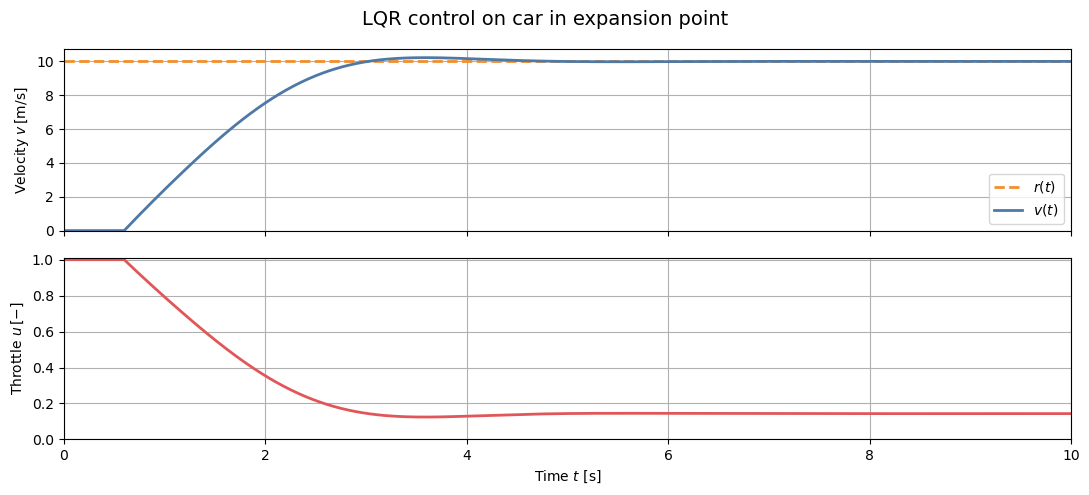

In [105]:
# LQR tuner in expansion point
u_set = u0

# Set init state to 0 to see speedup
init_state_LQR = np.array([
    0,                           # x
    0,                           # x_dot
])

v_LQR, u_LQR = simulation(init_state_LQR, actor_function=make_af_lqr(v_set=v_set, u_set=u_set, K=K_LQR))
show_plots(v_LQR, u_LQR, v_set=v_set, title="LQR control on car in expansion point")

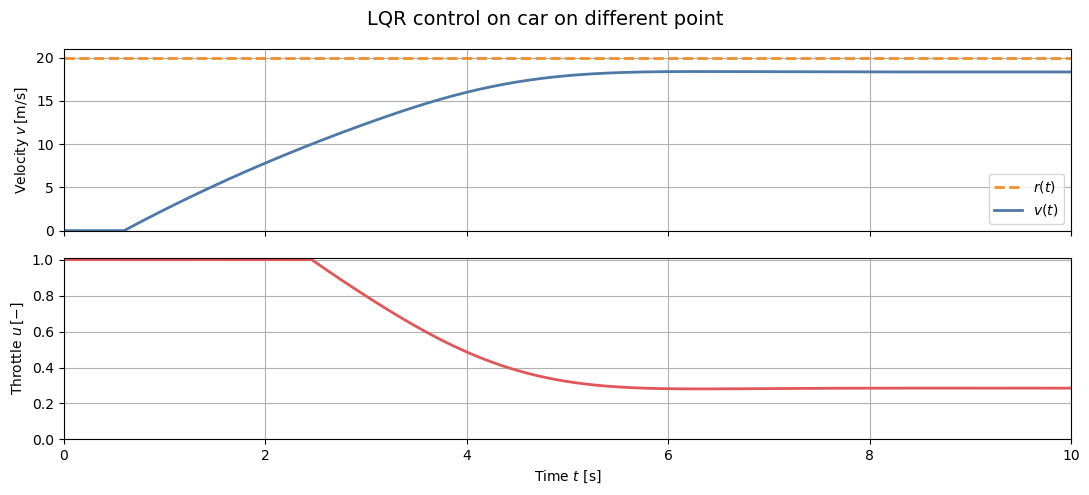

In [99]:
# LQR tuner out of expansion point
v_set_new = 20

# Set init state as 90 % to see speedup
init_state_LQR = np.array([
    0.0,                           # x
    0,                           # x_dot
])

v_LQR2, u_LQR2 = simulation(init_state_LQR, actor_function=make_af_lqr(v_set=v_set_new, u_set=u_set, K=K_LQR))
show_plots(v_LQR2, u_LQR2, v_set=v_set_new, title="LQR control on car on different point")

# LQI

In [109]:
# LQI expansion
A_LQI = np.array([[0, 1, 0],[0, -c/m, 0], [0, -1, 0]])

B_LQI = np.array([[0],[k/m*(1-u0)], [0]])


Q_LQI = np.diag([0, 0.01, 0.001])
R_LQI = np.array([[1]])

P_LQI = solve_continuous_are(A_LQI, B_LQI, Q_LQI, R_LQI)
K_LQI = np.linalg.solve(R_LQI, B_LQI.T @ P_LQI)   # = R^{-1} B^T P, shape (1,2)

print(K_LQI)

[[ 7.98984030e-18  1.11515881e-01 -3.16227766e-02]]


In [110]:
def make_af_lqi(v_set, u_set, K, u_max=1.0):
    K = np.asarray(K, dtype=float)
    z = 0.0

    def lqi_actor(state, t):
        nonlocal z
        # We need tilde (transformed) values in here
        x = np.asarray(state, dtype=float)
        v_tilde = x[1] - v_set
        z -= v_tilde * dt
        z = np.clip(z, -5, 5)

        x_tilde = np.array([0.0, v_tilde, z], dtype=float)

        du = -float(np.squeeze(K @ x_tilde))
        u = u_set + du          # Coordinate back-transformation to get absolute values
        return np.clip(u, 0, u_max)


    return lqi_actor


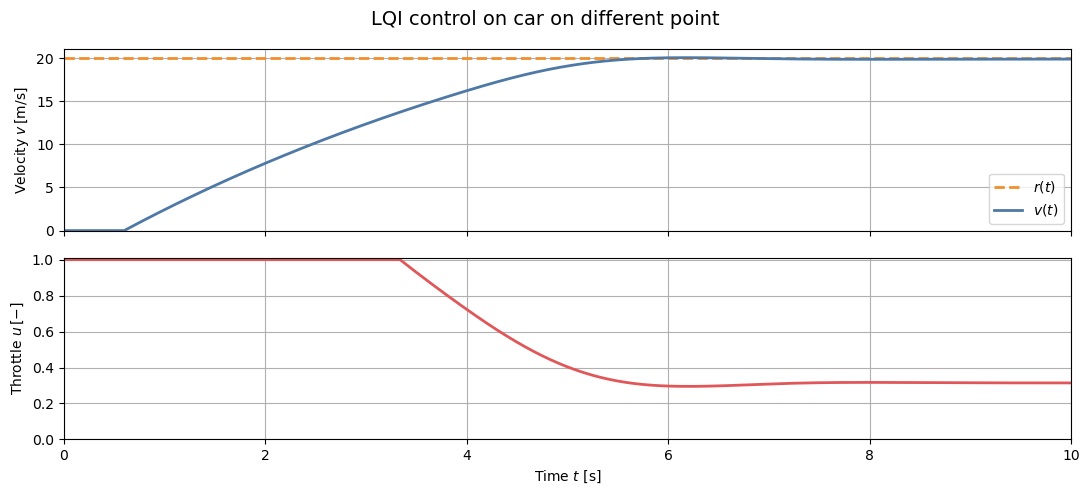

In [111]:
# LQI tuner out of expansion point

v_LQI, u_LQI = simulation(init_state_LQR, actor_function=make_af_lqi(v_set=v_set_new, u_set=u_set, K=K_LQI))
show_plots(v_LQI, u_LQI, v_set=v_set_new, title="LQI control on car on different point")

# Reinforcement learning

Super simple Soft-actor critic algorithm.

In [67]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
import os
from stable_baselines3.common.callbacks import BaseCallback

class SimpleControlEnv(gym.Env):
    def __init__(self, dt=1e-2, v_set=20.0, m=1200.0, k=4000.0, c=50.0, F_dist=0.0):
        super().__init__()
        self.dt = dt
        self.u_max = 1.0
        self.max_steps = 100

        # Fahrzeugparameter
        self.m = m
        self.k = k
        self.c = c
        self.F_dist = F_dist

        # Sollgeschwindigkeit
        self.v_set = v_set

        # State = v (Geschwindigkeit)
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([50.0, 50.0, 1.0], dtype=np.float32),   # u_prev in [0,1]
            dtype=np.float32
        )

        # Action space
        self.action_space = spaces.Box(
            low=np.array([0.0], dtype=np.float32),
            high=np.array([self.u_max], dtype=np.float32),
            dtype=np.float32
        )

        self.v = 0.0
        self.u_prev = 0.0
        self.step_count = 0


    def set_target_speed(self, v_set):
        """Sollgeschwindigkeit zur Laufzeit ändern."""
        self.v_set = float(v_set)


    # We use randomization of v_set and disturbance F_dist, so that our NN will be flexible!
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_count = 0

        # Anfangsgeschwindigkeit sinnvoll im erlaubten Bereich
        #self.F_dist = np.random.uniform(-50, 50)
        self.v = 0.0
        self.v_set = np.random.uniform(3.0, 30.0)
        self.u_prev = 0.0

        # Optional: v_set über reset(options=...) setzen
        if options is not None and "v_set" in options:
            self.v_set = float(options["v_set"])

        return np.array([self.v, self.v_set, self.u_prev], dtype=np.float32), {}

    def step(self, action):   
        self.step_count += 1
        u = float(np.clip(action[0], 0.0, self.u_max))

        # Non-linear dynamics
        v_dot = (self.k * (u - u**2 / 2) - self.c * self.v - self.F_dist) / self.m

        # Euler
        self.v = self.v + self.dt * v_dot

        # Error
        err = self.v_set - self.v
        du = u - self.u_prev
        self.u_prev = u

        # Cost function (reward)
        reward = -(err**2 + 0.001 * u**2 + 0.05 * du**2)

        terminated = False
        truncated = self.step_count >= self.max_steps

        obs = np.array([self.v, self.v_set, self.u_prev], dtype=np.float32)
        info = {"u": u, "v_set": self.v_set, "error": err}

        return obs, float(reward), terminated, truncated, info
    

class SaveEveryNEpisodesCallback(BaseCallback):
    def __init__(self, save_every_episodes=100, save_dir="RL", name_prefix="sac_controller", verbose=1):
        super().__init__(verbose)
        self.save_every_episodes = save_every_episodes
        self.save_dir = save_dir
        self.name_prefix = name_prefix
        self.episode_count = 0
        os.makedirs(save_dir, exist_ok=True)

    def _on_step(self) -> bool:
        # Bei nicht-vektorisierter Env ist dones ein Array mit Länge 1
        dones = self.locals.get("dones")
        if dones is None:
            return True

        # zählt abgeschlossene Episoden
        self.episode_count += int(dones[0])

        if self.episode_count > 0 and self.episode_count % self.save_every_episodes == 0:
            path = os.path.join(self.save_dir, f"{self.name_prefix}_ep{self.episode_count}")
            self.model.save(path)
            if self.verbose:
                print(f"[Checkpoint] gespeichert: {path}.zip")

        return True

In [ ]:
# Train model

# Create environment 
env = SimpleControlEnv(v_set=10)

# Callback: alle 10 Episoden speichern
save_cb = SaveEveryNEpisodesCallback(
    save_every_episodes=100,
    save_dir="RL",
    name_prefix="sac_controller"
)

# Create model and train 
model = SAC("MlpPolicy", env, verbose=0)
if False:
    model.learn(total_timesteps=500_000, callback=save_cb, progress_bar=True)

# Save (manuell zusätzlich)
model.save("RL/sac_controller")

Output()

[Checkpoint] gespeichert: RL/sac_controller_ep100.zip

[Checkpoint] gespeichert: RL/sac_controller_ep100.zip

[Checkpoint] gespeichert: RL/sac_controller_ep100.zip

[Checkpoint] gespeichert: RL/sac_controller_ep100.zip

...

[Checkpoint] gespeichert: RL/sac_controller_ep4900.zip

[Checkpoint] gespeichert: RL/sac_controller_ep4900.zip

[Checkpoint] gespeichert: RL/sac_controller_ep4900.zip

[Checkpoint] gespeichert: RL/sac_controller_ep4900.zip

[Checkpoint] gespeichert: RL/sac_controller_ep5000.zip

In [69]:
# Actor function SAC

def make_af_sac(model=None, v_set=10.0, episode=None):
    if model is None:
        if episode is None:
            raise ValueError("Choose episode.")
        model = SAC.load(f"RL/sac_controller_ep{episode}")

    u_prev = 0.0  # <- merkt sich letzte Aktion zwischen Funktionsaufrufen

    def rl_actor(state, t):
        nonlocal u_prev

        x = np.asarray(state, dtype=float)

        v = float(x[1])  # Annahme: state[1] = velocity
        obs = np.array([v, v_set, u_prev], dtype=np.float32)

        action, _ = model.predict(obs, deterministic=True)
        u = float(np.asarray(action).reshape(-1)[0])
        u = float(np.clip(u, 0.0, 1.0))

        u_prev = u  # <- für den nächsten Schritt merken
        return u

    return rl_actor

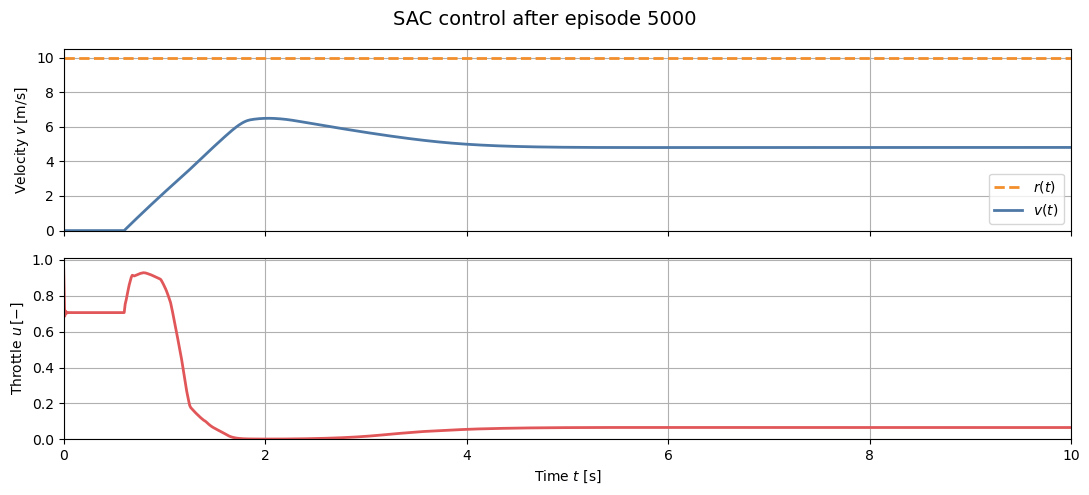

In [117]:
# Run model 
v_set_rl = 10

model = SAC.load("RL/sac_controller_ep5000")
af_sac = make_af_sac(model=model,v_set=v_set_rl)

v_RL, u_RL = simulation(init_state_LQR, actor_function=af_sac)
show_plots(v_RL, u_RL, v_set=v_set_rl, title="SAC control after episode 5000")